In [1]:
import os
import pathlib

import numpy as np
import cv2 as cv
from matplotlib import pyplot as plt

from video import Video

In [2]:
base_dir = pathlib.Path(os.getcwd())
input_dir = base_dir / "input"
output_dir = base_dir / "output"

In [3]:
video = Video(input_dir / "anime.mp4", verbose=True)

palette = np.load(output_dir / "0428_color_6_6_0.npy")
print()
print(f"num_palette_frames = {len(palette)}")
print(f"num_palette_colors = {palette.shape[1]}")

num_frames = 117538
height = 1040
width = 1920
fps = 23.9760
num_secs = 4902.3141
num_mins = 81.7052

num_palette_frames = 19589
num_palette_colors = 6


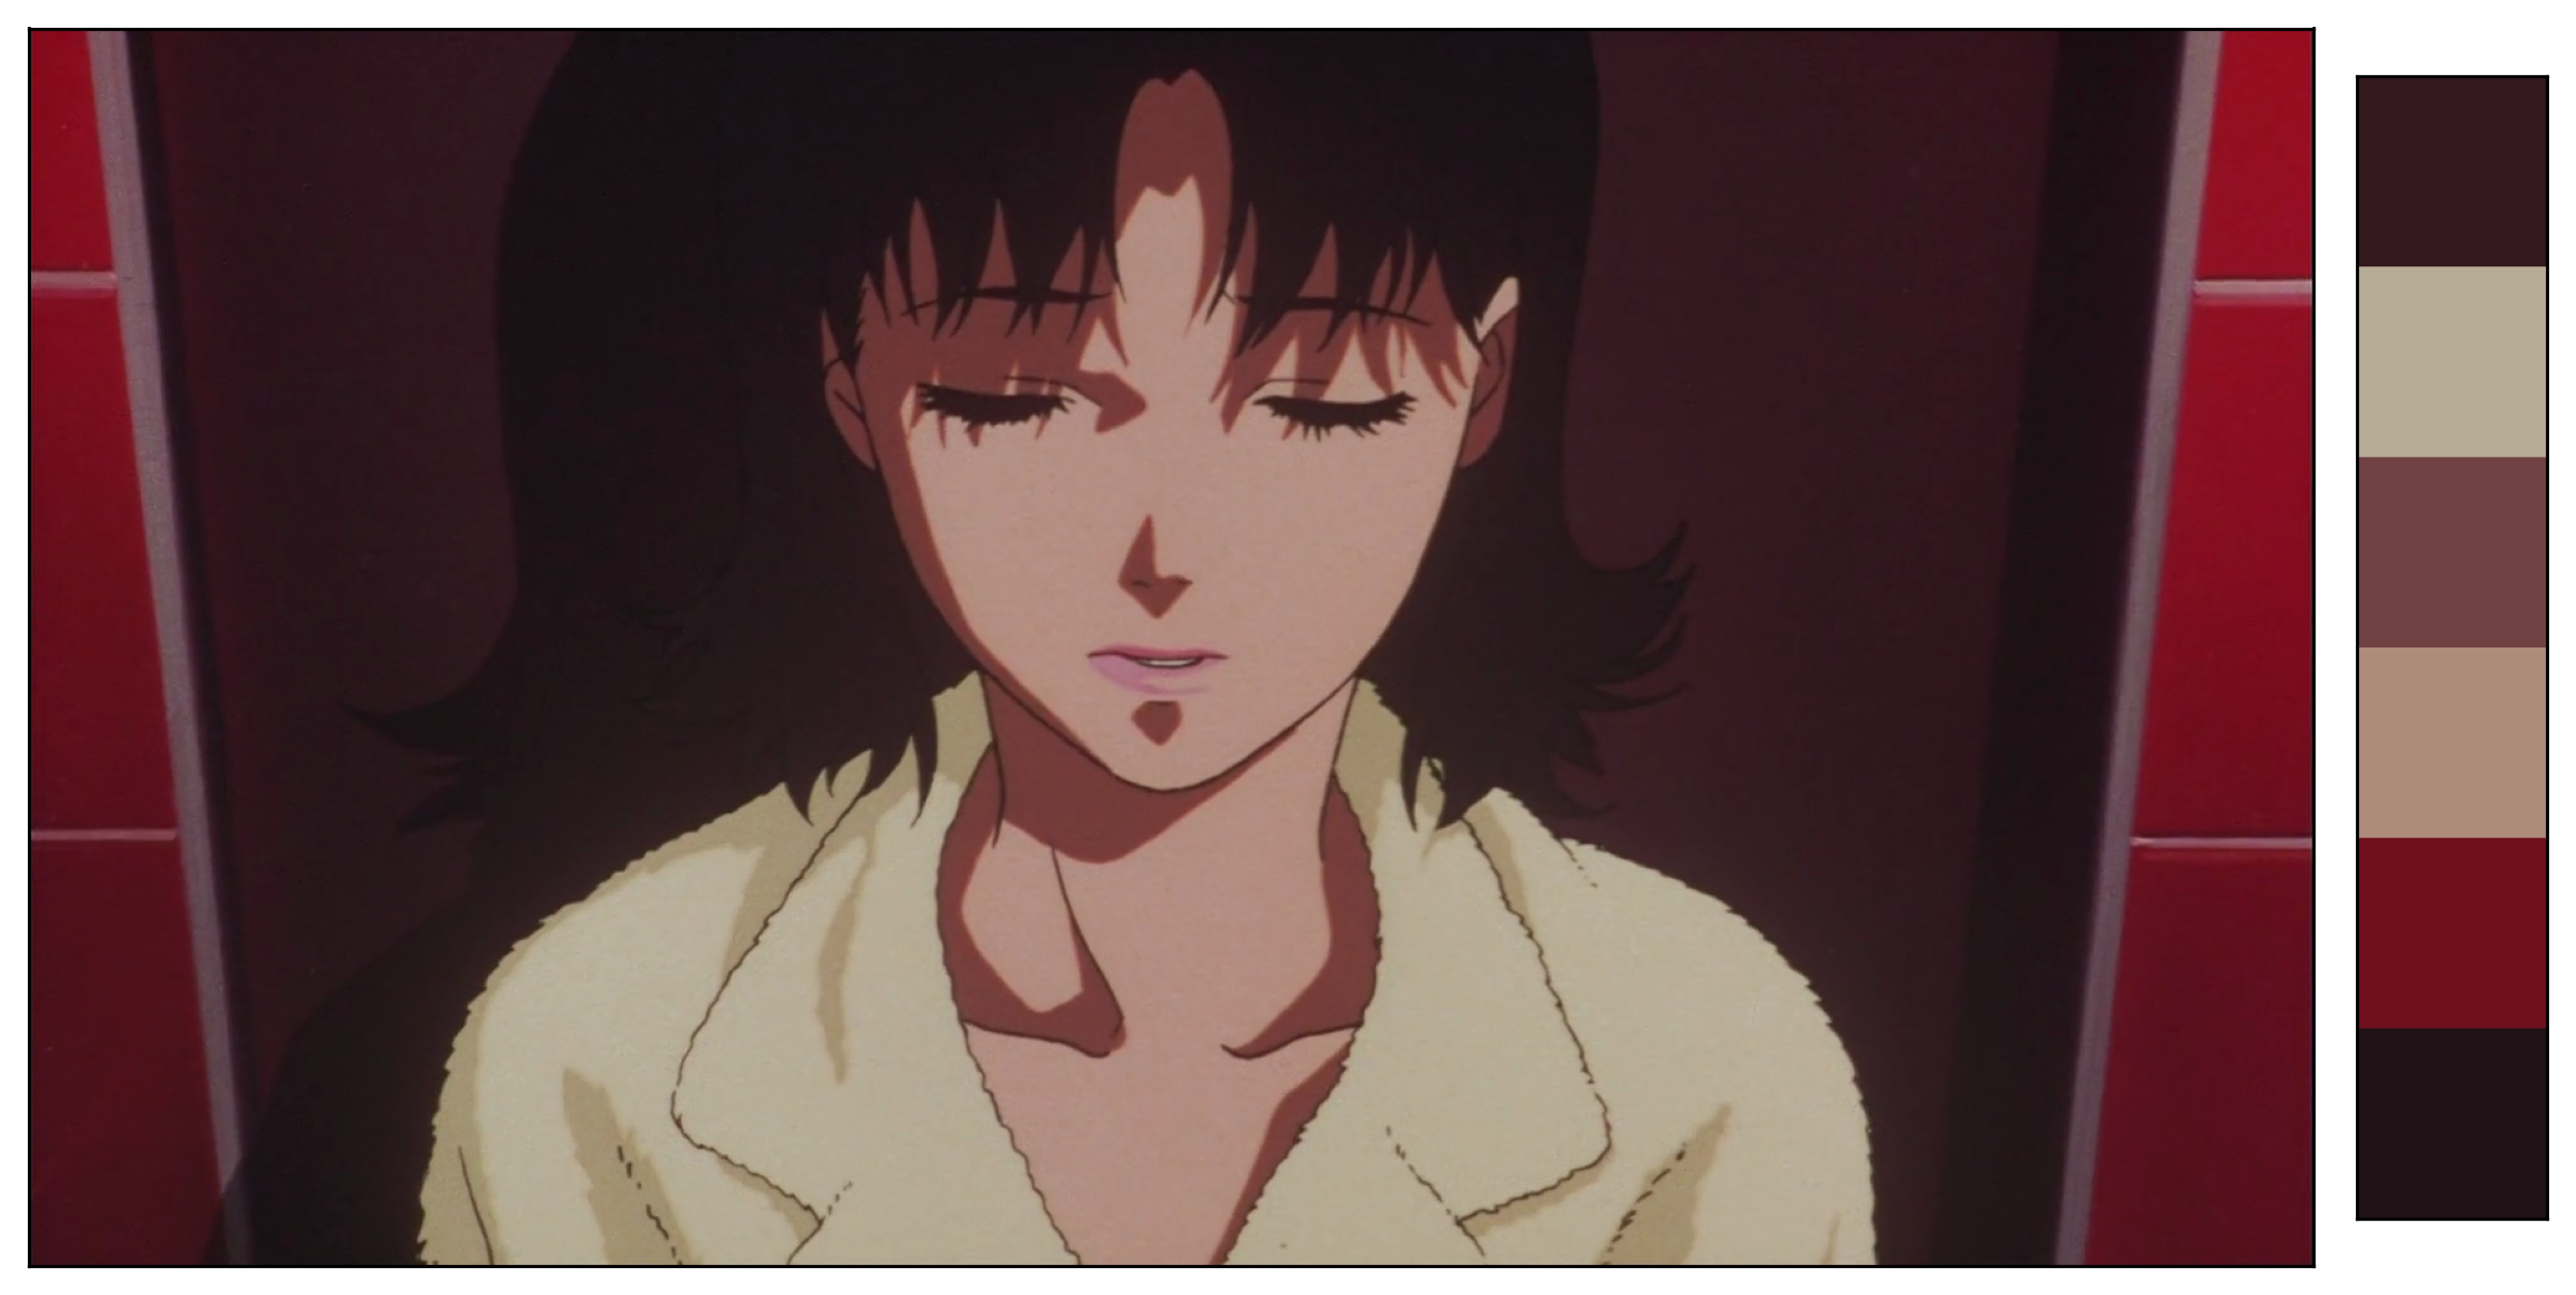

In [4]:
frame_idx = 66_000

frame = video[frame_idx]
frame = cv.cvtColor(frame, cv.COLOR_BGR2RGB)

p_frame = palette[frame_idx // 6]
p_frame = np.broadcast_to(p_frame[:, np.newaxis, :], (6, 25_600, 3)).reshape((960, 160, 3))
p_frame = cv.cvtColor(p_frame, cv.COLOR_BGR2RGB)

fig, axes = plt.subplots(1, 2, figsize=(9, 6), dpi=300, width_ratios=[1920, 160])

fig.patch.set_alpha(0)

axes[0].set_xticks([])
axes[0].set_yticks([])
axes[0].imshow(frame)
axes[1].set_xticks([])
axes[1].set_yticks([])
axes[1].imshow(p_frame)

plt.tight_layout()
plt.show()

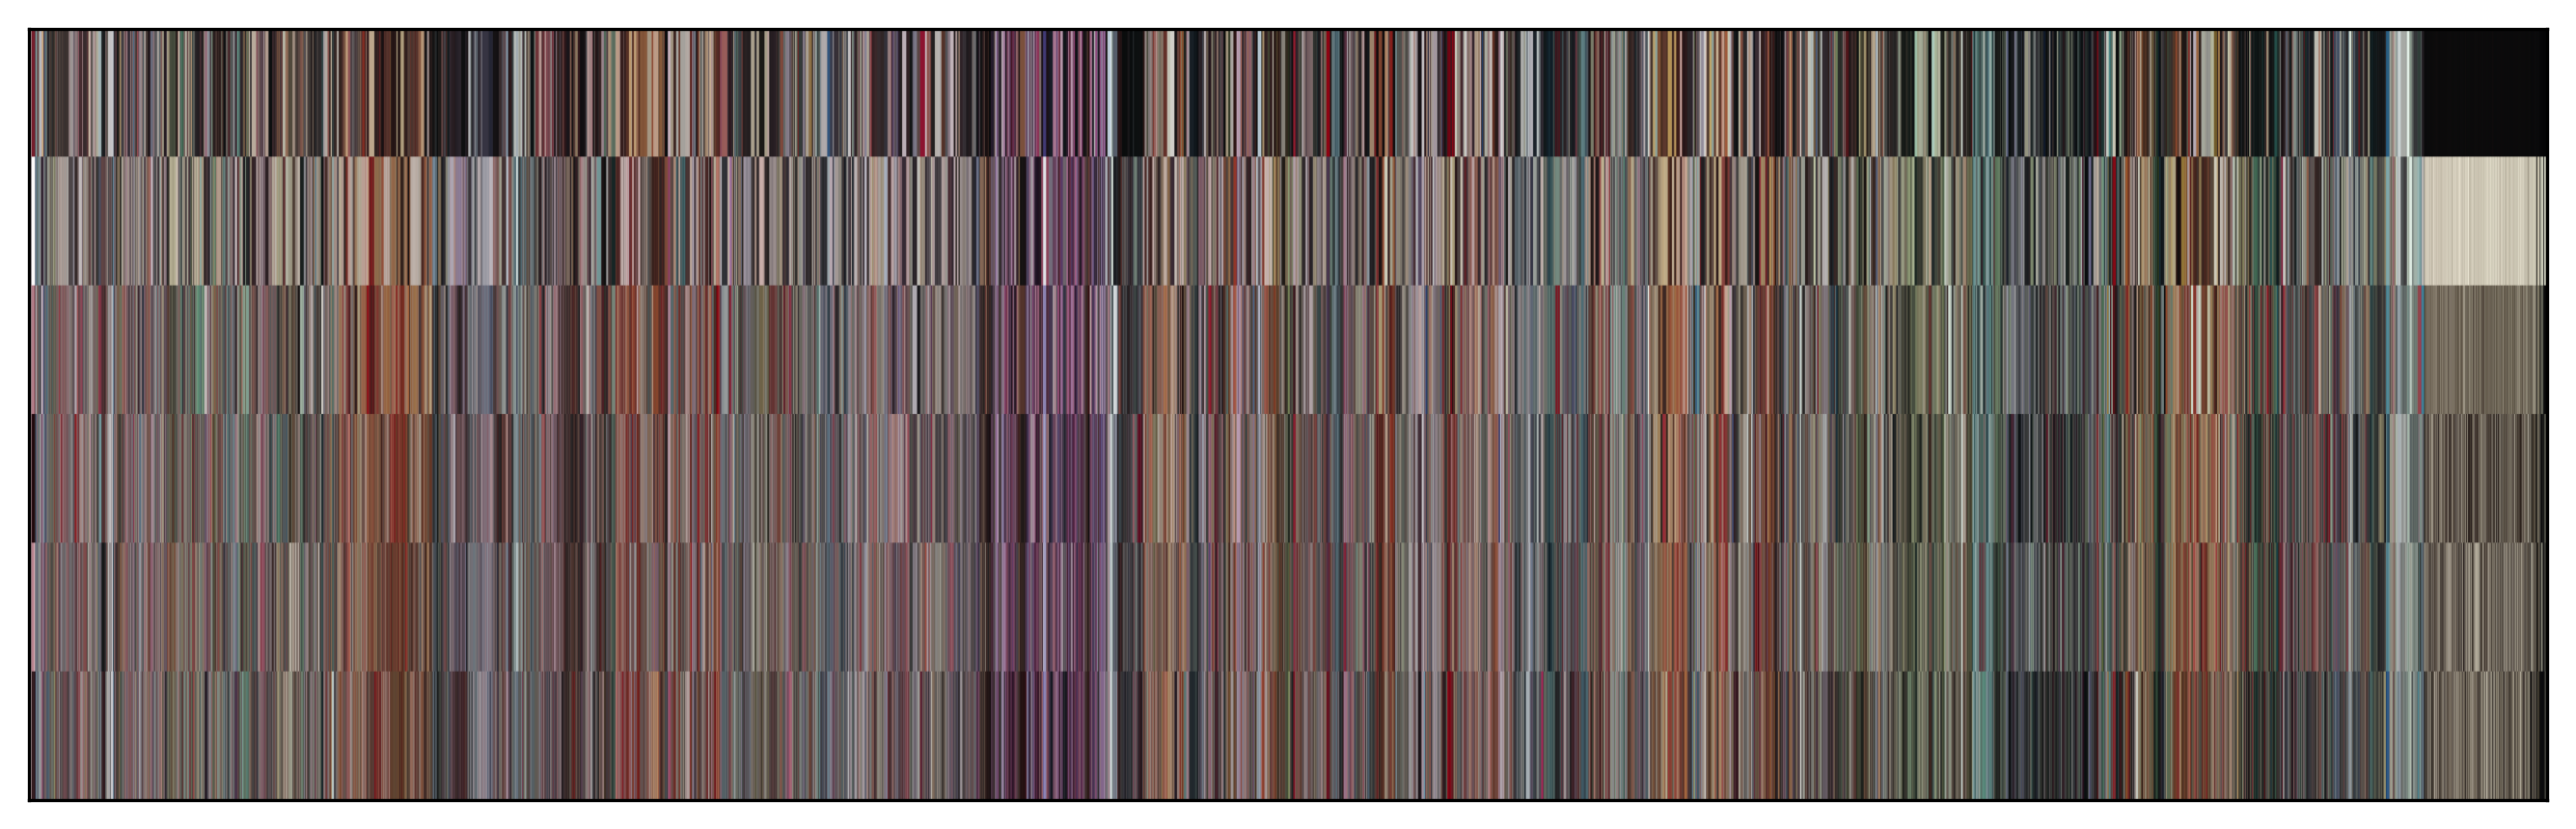

In [5]:
p = palette
p = np.broadcast_to(p.transpose((1, 0, 2))[:, np.newaxis], (6, 1_000, len(palette), 3)).reshape(6_000, len(palette), 3)
p = cv.cvtColor(p, cv.COLOR_BGR2RGB)

fig, ax = plt.subplots(figsize=(9, 6), dpi=300)

fig.patch.set_alpha(0)

ax.set_xticks([])
ax.set_yticks([])
ax.imshow(p)

plt.tight_layout()
plt.show()